In [ ]:
from google.colab import files
uploaded = files.upload()

Saving logins_sinteticos_analizador_localizacion_login.csv to logins_sinteticos_analizador_localizacion_login (1).csv


In [ ]:
import pandas as pd

archivo = "logins_sinteticos_analizador_localizacion_login.csv"
df = pd.read_csv(archivo)

print("Dimensiones del dataset:", df.shape)
df.head(10)

Dimensiones del dataset: (71, 10)


,user_id,timestamp,ip,known_location,declared_city,declared_country,user_agent,device_type,network_type,scenario_type
0,u001,2026-05-01 10:15:00,181.50.10.59,Bogota,Bogota,Colombia,Chrome Windows,desktop,residential,habitual
1,u001,2026-05-01 18:07:00,181.50.10.8,Bogota,Bogota,Colombia,Chrome Windows,desktop,corporate,habitual
2,u001,2026-05-02 16:05:00,181.50.10.153,Bogota,Bogota,Colombia,Chrome Windows,desktop,mobile,habitual
3,u001,2026-05-02 18:06:00,181.50.10.175,Bogota,Bogota,Colombia,Chrome Windows,desktop,corporate,habitual
4,u001,2026-05-03 08:01:00,181.50.10.25,Bogota,Bogota,Colombia,Chrome Windows,desktop,residential,habitual
5,u001,2026-05-03 09:32:00,181.50.10.156,Bogota,Bogota,Colombia,Chrome Windows,desktop,residential,habitual
6,u001,2026-05-04 16:12:00,181.50.10.185,Bogota,Bogota,Colombia,Chrome Windows,desktop,corporate,habitual
7,u001,2026-05-04 18:34:00,181.50.10.109,Bogota,Bogota,Colombia,Chrome Windows,desktop,residential,habitual
8,u001,2026-05-05 09:44:00,181.50.10.110,Bogota,Bogota,Colombia,Chrome Windows,desktop,mobile,habitual
9,u001,2026-05-05 14:37:00,181.50.10.73,Bogota,Bogota,Colombia,Chrome Windows,desktop,residential,habitual


In [ ]:
import pandas as pd

# =========================
# CARGA DE DATOS
# =========================
archivo = "logins_sinteticos_analizador_localizacion_login.csv"
df = pd.read_csv(archivo)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Ordenar por usuario y tiempo
df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

# =========================
# FUNCIÓN DE RIESGO
# =========================
def calcular_riesgo(row, previous_row=None):
    score = 0
    reasons = []

    # Regla 1: localización distinta a la habitual
    if pd.notna(row["declared_city"]) and pd.notna(row["known_location"]):
        if str(row["declared_city"]).lower() != str(row["known_location"]).lower():
            score += 25
            reasons.append("Localización distinta a la habitual")

    # Regla 2: cambio geográfico respecto al evento anterior
    if previous_row is not None:
        if row["declared_city"] != previous_row["declared_city"]:
            score += 20
            reasons.append("Cambio geográfico respecto al evento anterior")

    # Regla 3: horario atípico
    hour = row["timestamp"].hour
    if hour < 6 or hour > 22:
        score += 10
        reasons.append("Horario atípico")

    # Regla 4: red sospechosa
    if row["network_type"] in ["proxy", "hosting"]:
        score += 20
        reasons.append(f"Red sospechosa: {row['network_type']}")

    # Regla 5: dispositivo distinto al evento anterior
    if previous_row is not None:
        if row["device_type"] != previous_row["device_type"]:
            score += 10
            reasons.append("Cambio de dispositivo")

    # Clasificación final
    if score >= 60:
        level = "alto"
    elif score >= 30:
        level = "medio"
    else:
        level = "bajo"

    return score, level, "; ".join(reasons)

# =========================
# APLICAR SCORING
# =========================
risk_scores = []
risk_levels = []
risk_reasons = []

for user_id, group in df.groupby("user_id", sort=False):
    previous_row = None
    for idx in group.index:
        row = df.loc[idx]
        score, level, reasons = calcular_riesgo(row, previous_row)

        risk_scores.append((idx, score))
        risk_levels.append((idx, level))
        risk_reasons.append((idx, reasons))

        previous_row = row

for idx, score in risk_scores:
    df.loc[idx, "risk_score"] = score

for idx, level in risk_levels:
    df.loc[idx, "risk_level"] = level

for idx, reasons in risk_reasons:
    df.loc[idx, "risk_reasons"] = reasons

# =========================
# VER RESULTADOS
# =========================
df.head(20)

,user_id,timestamp,ip,known_location,declared_city,declared_country,user_agent,device_type,network_type,scenario_type,risk_score,risk_level,risk_reasons
0,u001,2026-05-01 10:15:00,181.50.10.59,Bogota,Bogota,Colombia,Chrome Windows,desktop,residential,habitual,0.0,bajo,
1,u001,2026-05-01 18:07:00,181.50.10.8,Bogota,Bogota,Colombia,Chrome Windows,desktop,corporate,habitual,0.0,bajo,
2,u001,2026-05-02 16:05:00,181.50.10.153,Bogota,Bogota,Colombia,Chrome Windows,desktop,mobile,habitual,0.0,bajo,
3,u001,2026-05-02 18:06:00,181.50.10.175,Bogota,Bogota,Colombia,Chrome Windows,desktop,corporate,habitual,0.0,bajo,
4,u001,2026-05-03 08:01:00,181.50.10.25,Bogota,Bogota,Colombia,Chrome Windows,desktop,residential,habitual,0.0,bajo,
5,u001,2026-05-03 09:32:00,181.50.10.156,Bogota,Bogota,Colombia,Chrome Windows,desktop,residential,habitual,0.0,bajo,
6,u001,2026-05-04 16:12:00,181.50.10.185,Bogota,Bogota,Colombia,Chrome Windows,desktop,corporate,habitual,0.0,bajo,
7,u001,2026-05-04 18:34:00,181.50.10.109,Bogota,Bogota,Colombia,Chrome Windows,desktop,residential,habitual,0.0,bajo,
8,u001,2026-05-05 09:44:00,181.50.10.110,Bogota,Bogota,Colombia,Chrome Windows,desktop,mobile,habitual,0.0,bajo,
9,u001,2026-05-05 14:37:00,181.50.10.73,Bogota,Bogota,Colombia,Chrome Windows,desktop,residential,habitual,0.0,bajo,


In [8]:
# Guardar resultados completos
df.to_csv("resultados_analizador_localizacion_login.csv", index=False)

# Resumen por nivel de riesgo
resumen = df.groupby("risk_level").size().reset_index(name="cantidad")
resumen.to_csv("resumen_riesgo_analizador_login.csv", index=False)

print("Archivos guardados correctamente.")
print("1. resultados_analizador_localizacion_login.csv")
print("2. resumen_riesgo_analizador_login.csv")

Archivos guardados correctamente.
1. resultados_analizador_localizacion_login.csv
2. resumen_riesgo_analizador_login.csv


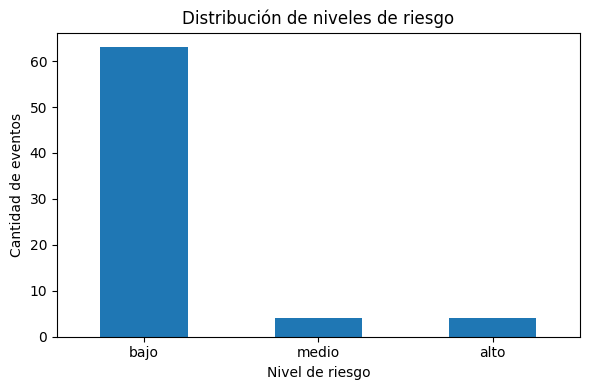

In [ ]:
import matplotlib.pyplot as plt

conteo = df["risk_level"].value_counts()

plt.figure(figsize=(6,4))
conteo.plot(kind="bar")
plt.title("Distribución de niveles de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()